In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前训练设备: {device}")

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

当前训练设备: cpu


In [7]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

# 创建数据加载器
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集样本数: {len(train_dataset)}")
print(f"测试集样本数: {len(test_dataset)}")

训练集样本数: 60000
测试集样本数: 10000


In [9]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1)
        self.pool = nn.MaxPool2d(2, 2)
        
      
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        
        # 全连接层
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        
        x = x.view(-1, 64 * 5 * 5)
        x = self.dropout1(x)
        
        x = self.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x


model = MNIST_CNN().to(device)
print("模型结构：")
print(model)

模型结构：
MNIST_CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total_samples = 0

    for data, target in loader:
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()       # 梯度清零
        output = model(data)        # 前向传播
        loss = criterion(output, target)  # 计算损失
        loss.backward()             # 反向传播
        optimizer.step()            # 更新参数

        total_loss += loss.item() * data.size(0)
        _, pred = torch.max(output, 1)
        correct += (pred == target).sum().item()
        total_samples += target.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples
    return avg_loss, accuracy


def test_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad():  # 测试阶段不计算梯度
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)

            total_loss += loss.item() * data.size(0)
            _, pred = torch.max(output, 1)
            correct += (pred == target).sum().item()
            total_samples += target.size(0)

    avg_loss = total_loss / total_samples
    accuracy = correct / total_samples
    return avg_loss, accuracy

In [15]:

num_epochs = 10
learning_rate = 0.001


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


train_loss_hist = []
train_acc_hist = []
test_loss_hist = []
test_acc_hist = []

# 开始训练
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = test_one_epoch(model, test_loader, criterion, device)

    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    test_loss_hist.append(test_loss)
    test_acc_hist.append(test_acc)

    print(f"Epoch {epoch:2d}/{num_epochs} | "
      f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
      f"Test Loss: {test_loss:.4f}  Acc: {test_acc:.4f}",
      flush=True)

print(f"\n✅ 最终测试准确率: {test_acc_hist[-1]:.4f} ({test_acc_hist[-1]*100:.2f}%)")

Epoch  1/10 | Train Loss: 0.2278  Acc: 0.9304 | Test Loss: 0.0549  Acc: 0.9811
Epoch  2/10 | Train Loss: 0.0871  Acc: 0.9739 | Test Loss: 0.0419  Acc: 0.9853
Epoch  3/10 | Train Loss: 0.0674  Acc: 0.9803 | Test Loss: 0.0279  Acc: 0.9902
Epoch  4/10 | Train Loss: 0.0551  Acc: 0.9835 | Test Loss: 0.0264  Acc: 0.9910
Epoch  5/10 | Train Loss: 0.0487  Acc: 0.9855 | Test Loss: 0.0263  Acc: 0.9916
Epoch  6/10 | Train Loss: 0.0440  Acc: 0.9862 | Test Loss: 0.0288  Acc: 0.9906
Epoch  7/10 | Train Loss: 0.0417  Acc: 0.9876 | Test Loss: 0.0232  Acc: 0.9922
Epoch  8/10 | Train Loss: 0.0378  Acc: 0.9882 | Test Loss: 0.0231  Acc: 0.9927
Epoch  9/10 | Train Loss: 0.0357  Acc: 0.9890 | Test Loss: 0.0284  Acc: 0.9912
Epoch 10/10 | Train Loss: 0.0327  Acc: 0.9894 | Test Loss: 0.0223  Acc: 0.9928

✅ 最终测试准确率: 0.9928 (99.28%)


📄 训练曲线图已保存为 mnist_training_curve.pdf


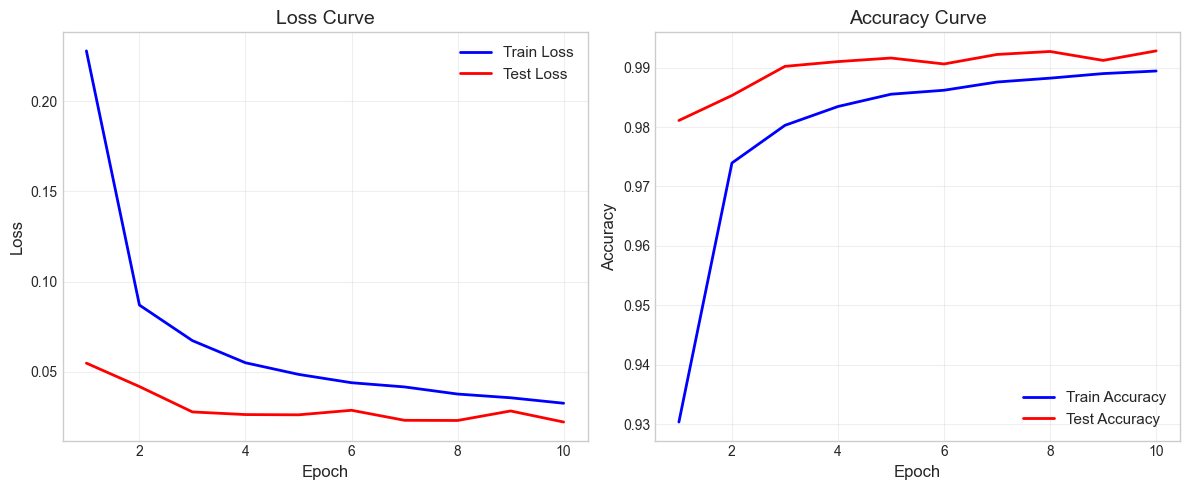

In [17]:
plt.style.use("seaborn-v0_8-whitegrid")
epochs = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


ax1.plot(epochs, train_loss_hist, "b-", linewidth=2, label="Train Loss")
ax1.plot(epochs, test_loss_hist, "r-", linewidth=2, label="Test Loss")
ax1.set_title("Loss Curve", fontsize=14)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)


ax2.plot(epochs, train_acc_hist, "b-", linewidth=2, label="Train Accuracy")
ax2.plot(epochs, test_acc_hist, "r-", linewidth=2, label="Test Accuracy")
ax2.set_title("Accuracy Curve", fontsize=14)
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)


plt.tight_layout()


plt.savefig("mnist_training_curve.pdf", format="pdf", dpi=300, bbox_inches="tight")
print("📄 训练曲线图已保存为 mnist_training_curve.pdf")


plt.show()